## Task 4.5 – Text Classification with RNN, LSTM & Word2Vec Embeddings

## Section 1 — Environment Setup & Library Imports


In [28]:
!pip install gradio -q
!pip install gensim -q
!pip install wordcloud -q
print("Libraries installed!")

Libraries installed!


In [29]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Core Imports
import os
import re
import string
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Section 2 — Dataset Loading & Exploratory Data Analysis

### 4.5.1 – Task 1: Load the Dataset


In [31]:
#Extract and Load Dataset from Google Drive
zip_path = '/content/drive/MyDrive/AI/Sarcastic or Not Sarcastic Dataset.zip'

# Extract
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/sarcasm')
print("Extracted!")

# Check files
for root, dirs, files in os.walk('/content/sarcasm'):
    for f in files:
        print(os.path.join(root, f))

Extracted!
/content/sarcasm/8. Sarcastic or Not Sarcastic Dataset/8.Description Sarcastic or Not Dataset.txt
/content/sarcasm/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv


In [32]:
# Load CSV
csv_path = '/content/sarcasm/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv'
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (28619, 2)

Columns: ['headline', 'is_sarcastic']

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [33]:
# Dataset Overview
print(" Dataset Overview ")
print(f"Total samples     : {len(df)}")
print(f"Sarcastic (1)     : {df['is_sarcastic'].sum()} ({df['is_sarcastic'].mean()*100:.1f}%)")
print(f"Not Sarcastic (0) : {(df['is_sarcastic']==0).sum()} ({(df['is_sarcastic']==0).mean()*100:.1f}%)")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nAvg headline length: {df['headline'].str.split().str.len().mean():.1f} words")
print(f"Max headline length: {df['headline'].str.split().str.len().max()} words")
print(f"Min headline length: {df['headline'].str.split().str.len().min()} words")

 Dataset Overview 
Total samples     : 28619
Sarcastic (1)     : 13634 (47.6%)
Not Sarcastic (0) : 14985 (52.4%)

Missing values:
headline        0
is_sarcastic    0
dtype: int64

Avg headline length: 10.0 words
Max headline length: 151 words
Min headline length: 2 words


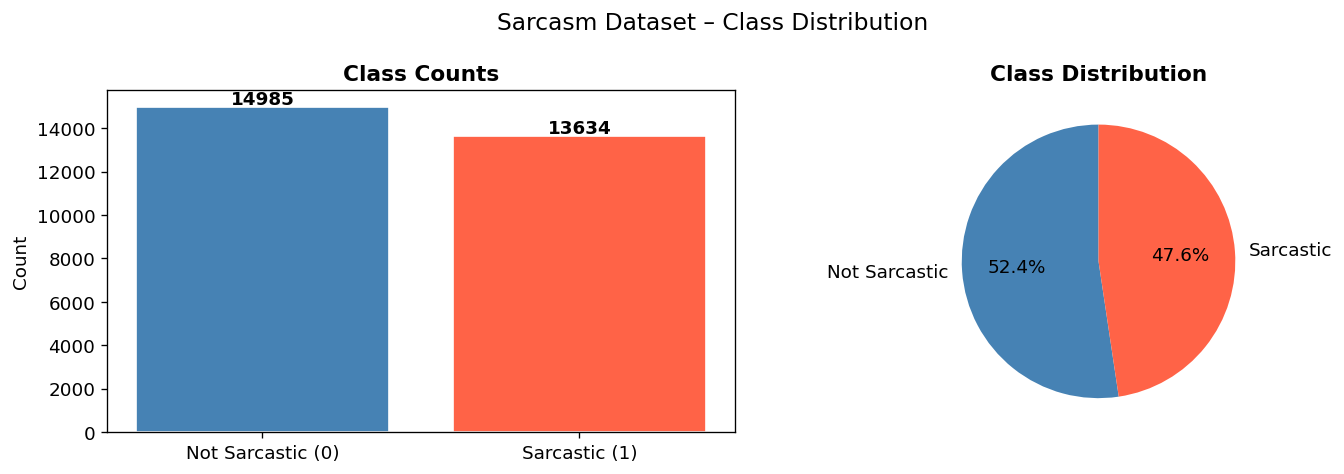

In [34]:
# Class Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sarcasm Dataset – Class Distribution', fontsize=14)

# Bar chart
counts = df['is_sarcastic'].value_counts()
axes[0].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Counts')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Sarcastic', 'Sarcastic'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

Word Count Statistics by Class:
                count   mean   std  min  25%   50%   75%    max
is_sarcastic                                                   
0             14985.0   9.82  2.89  2.0  8.0  10.0  12.0   38.0
1             13634.0  10.31  3.85  2.0  8.0  10.0  13.0  151.0


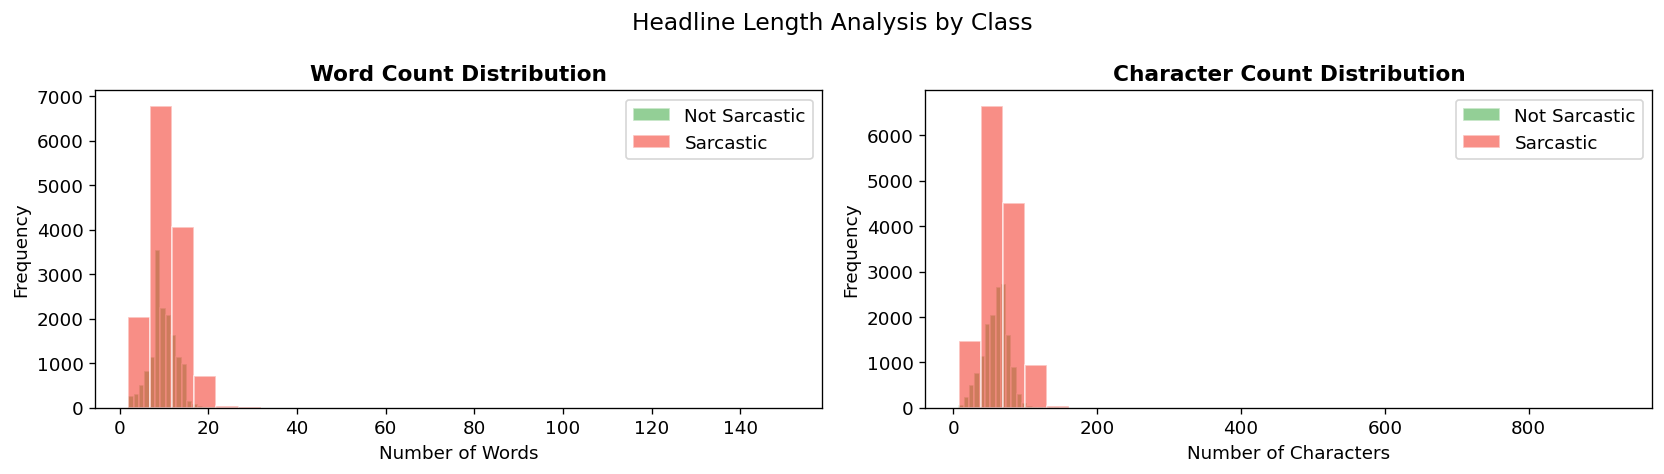


Observation: Sarcastic headlines tend to be slightly longer, using more elaborate phrasing.


In [35]:
#  Headline Length Analysis
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

print("Word Count Statistics by Class:")
print(df.groupby('is_sarcastic')['word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Headline Length Analysis by Class', fontsize=14)

for label, color, name in [(0,'#4CAF50','Not Sarcastic'), (1,'#F44336','Sarcastic')]:
    axes[0].hist(df[df['is_sarcastic']==label]['word_count'], bins=30,
                 alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(df[df['is_sarcastic']==label]['char_count'], bins=30,
                 alpha=0.6, color=color, label=name, edgecolor='white')

axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Character Count Distribution')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', bbox_inches='tight')
plt.show()
print("\nObservation: Sarcastic headlines tend to be slightly longer, using more elaborate phrasing.")

# Section 3 — Text Preprocessing & Cleaning

### 4.5.1 – Task 2: Clean the Text


In [36]:
#Text Cleaning Function
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Contractions dictionary
contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "couldn't": "could not",
    "shouldn't": "should not", "wouldn't": "would not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "he's": "he is", "she's": "she is", "they're": "they are",
    "we're": "we are", "that's": "that is", "there's": "there is"
}

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Expand contractions
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
print("Cleaning text...")
df['cleaned'] = df['headline'].apply(clean_text)

# Show before/after
print("\nBefore vs After Cleaning:")
for i in range(3):
    print(f"\nOriginal : {df['headline'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned'].iloc[i]}")

Cleaning text...

Before vs After Cleaning:

Original : thirtysomething scientists unveil doomsday clock of hair loss
Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

Original : dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned  : dem rep totally nail congress falling short gender racial equality

Original : eat your veggies: 9 deliciously different recipes
Cleaned  : eat veggie deliciously different recipe


### 4.5.1 – Task 3: Visualize the Cleaned Data

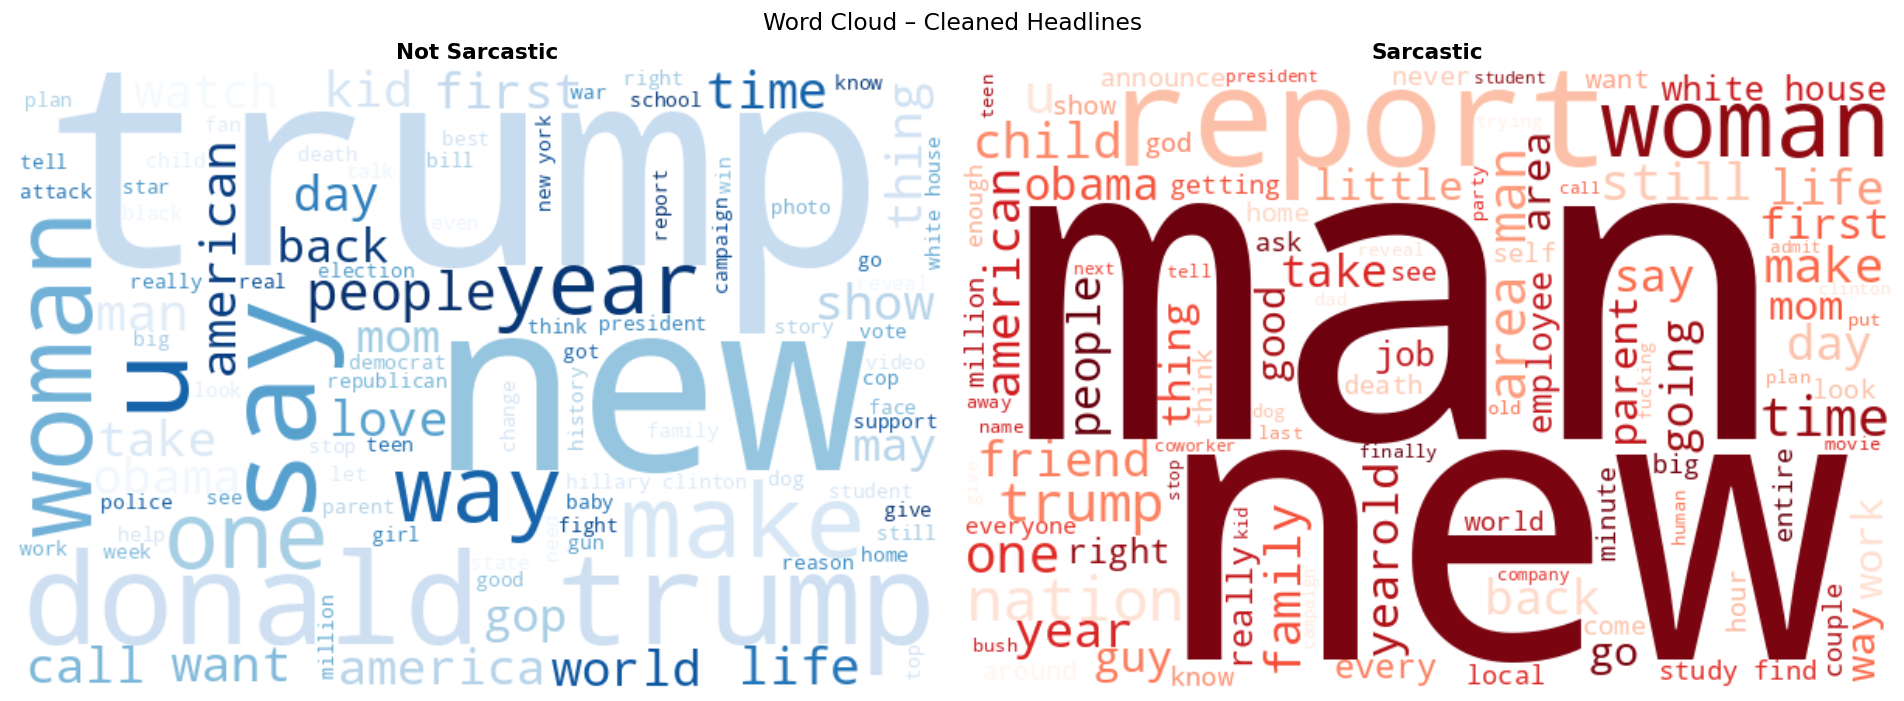

In [37]:
# Word Cloud Visualization
!pip install wordcloud -q
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Cloud – Cleaned Headlines', fontsize=14)

for idx, (label, title, color) in enumerate([
    (0, 'Not Sarcastic', 'Blues'),
    (1, 'Sarcastic', 'Reds')
]):
    text = ' '.join(df[df['is_sarcastic']==label]['cleaned'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=13)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

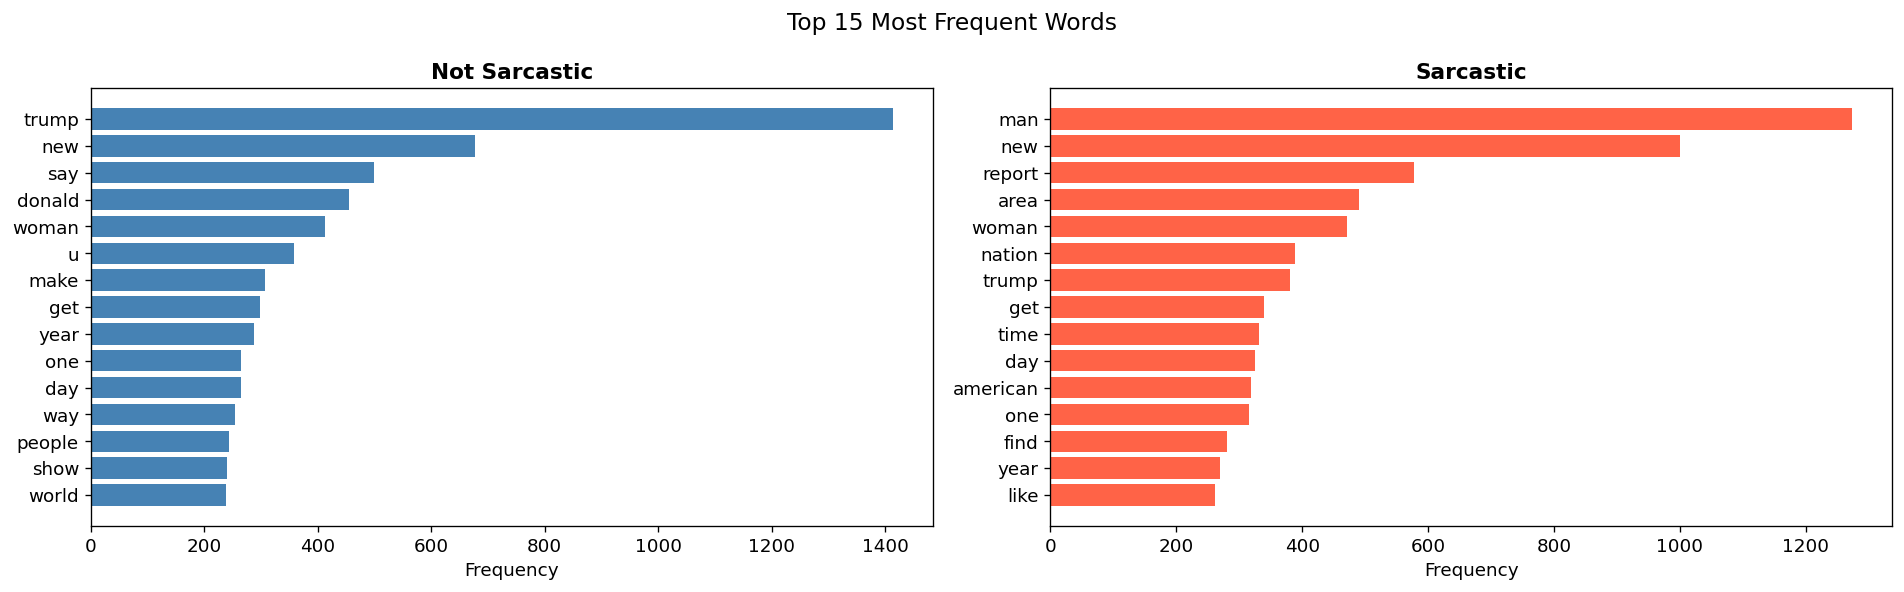

In [38]:
# Most Frequent Words
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top 15 Most Frequent Words', fontsize=14)

for idx, (label, title, color) in enumerate([
    (0, 'Not Sarcastic', 'steelblue'),
    (1, 'Sarcastic', 'tomato')
]):
    words = ' '.join(df[df['is_sarcastic']==label]['cleaned']).split()
    common = Counter(words).most_common(15)
    words_list, counts = zip(*common)
    axes[idx].barh(words_list[::-1], counts[::-1], color=color)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

Section 4: Tokenization & Sequence Padding

4.5.1 – Task 4: Tokenization and Padding

In [39]:
#Train/Test Split
X = df['cleaned'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Train class balance: {y_train.mean()*100:.1f}% sarcastic")
print(f"Test class balance : {y_test.mean()*100:.1f}% sarcastic")

Training samples : 22895
Test samples     : 5724
Train class balance: 47.6% sarcastic
Test class balance : 47.6% sarcastic


In [40]:
# Tokenization
VOCAB_SIZE = 20000  # top 20k most frequent words
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)  # fit only on training data

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")
print(f"\nSample sequence:")
print(f"Text    : {X_train[0]}")
print(f"Sequence: {X_train_seq[0]}")

Vocabulary size: 22552

Sample sequence:
Text    : paramount executive snap script begin studio logo fading establishing shot actual mountain
Sequence: [4198, 597, 3379, 2678, 377, 1274, 3380, 6585, 8418, 357, 2316, 2187]


In [41]:
# Percentile-Based Padding
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))  # 95th percentile
print(f"95th percentile sequence length: {MAX_LEN}")
print(f"Max sequence length            : {max(seq_lengths)}")
print(f"Mean sequence length           : {np.mean(seq_lengths):.1f}")
print(f"Using MAX_LEN = {MAX_LEN} for padding")

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape : {X_test_pad.shape}")

95th percentile sequence length: 11
Max sequence length            : 106
Mean sequence length           : 7.1
Using MAX_LEN = 11 for padding

X_train_pad shape: (22895, 11)
X_test_pad shape : (5724, 11)


Section 5: Model 1 – Simple RNN

### 4.5.2 – Model 1: Simple RNN with Trainable Embedding

In [42]:
#  Build Simple RNN Model
EMBEDDING_DIM = 64

def build_rnn_model():
    model = models.Sequential(name='Simple_RNN')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE,
                               output_dim=EMBEDDING_DIM,
                               input_length=MAX_LEN))
    model.add(layers.SimpleRNN(64, return_sequences=False))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # binary classification
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
#  Compile & Train RNN
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_rnn = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
]

import time
print("Training Simple RNN...")
start = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_rnn,
    verbose=1
)

rnn_time = time.time() - start
print(f"\nRNN Training time: {rnn_time/60:.2f} minutes")

Training Simple RNN...
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7430 - loss: 0.5041 - val_accuracy: 0.8083 - val_loss: 0.4113
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9228 - loss: 0.1951 - val_accuracy: 0.7878 - val_loss: 0.4949
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9806 - loss: 0.0574 - val_accuracy: 0.7817 - val_loss: 0.7380
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.0302 - val_accuracy: 0.7476 - val_loss: 1.0757
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

RNN Training time: 0.25 minutes


### 4.5.3 – Model 1: Training & Evaluation

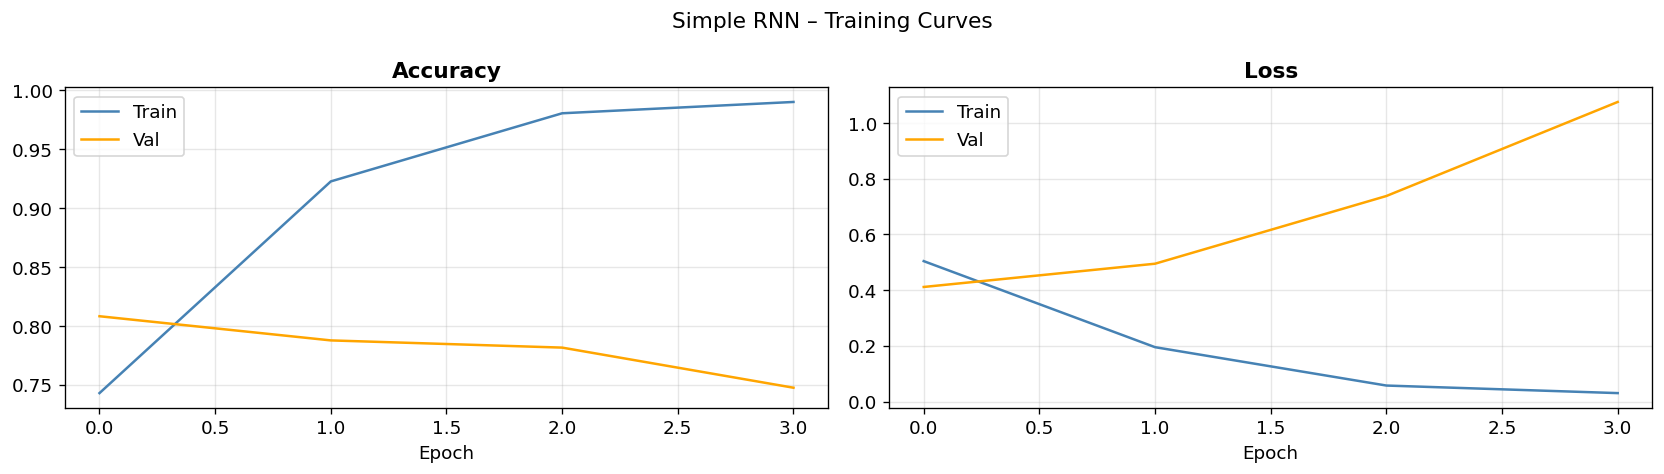

In [44]:
# Plot Training Curves (helper function)
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{title} – Training Curves', fontsize=13)

    axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

plot_history(history_rnn, 'Simple RNN')

In [45]:
#Evaluate RNN
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()

print(f"Simple RNN – Test Accuracy: {rnn_acc*100:.2f}%")
print(f"Simple RNN – Test Loss    : {rnn_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=['Not Sarcastic', 'Sarcastic']))

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Simple RNN – Test Accuracy: 79.89%
Simple RNN – Test Loss    : 0.4257

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.87      0.82      2997
    Sarcastic       0.83      0.72      0.77      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



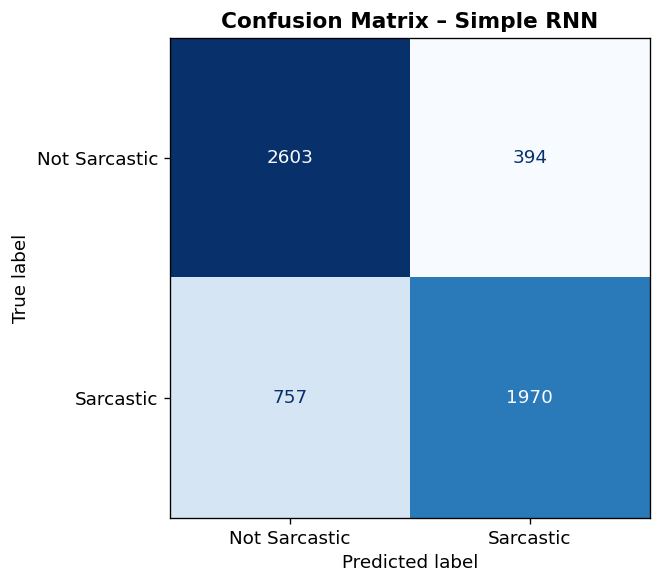

In [46]:
#  Confusion Matrix – RNN
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn,
                               display_labels=['Not Sarcastic', 'Sarcastic'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Simple RNN')
plt.tight_layout()
plt.savefig('cm_rnn.png', dpi=150)
plt.show()

Section 6: Model 2 – LSTM

### 4.5.2 – Model 2: LSTM with Trainable Embedding Layer

In [47]:
#Build LSTM Model
def build_lstm_model():
    model = models.Sequential(name='LSTM_Model')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE,
                               output_dim=EMBEDDING_DIM,
                               input_length=MAX_LEN))
    model.add(layers.LSTM(128, return_sequences=True))
    model.add(layers.Dropout(0.3))
    model.add(layers.LSTM(64, return_sequences=False))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile & Train LSTM
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training LSTM...")
start = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

lstm_time = time.time() - start
print(f"\nLSTM Training time: {lstm_time/60:.2f} minutes")

Training LSTM...
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7434 - loss: 0.5021 - val_accuracy: 0.8017 - val_loss: 0.4254
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8909 - loss: 0.2696 - val_accuracy: 0.7869 - val_loss: 0.5040
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9517 - loss: 0.1391 - val_accuracy: 0.7690 - val_loss: 0.6157
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9692 - loss: 0.0924 - val_accuracy: 0.7712 - val_loss: 0.8747
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

LSTM Training time: 0.44 minutes


### 4.5.3 – Model 2: Training & Evaluation

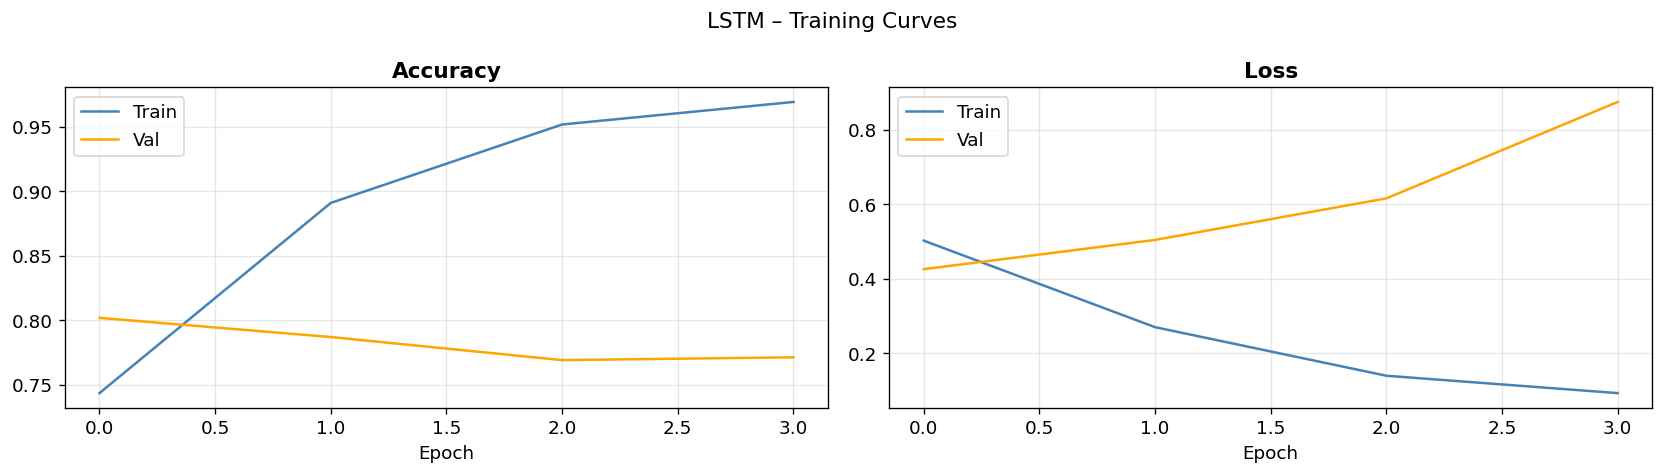

In [49]:
plot_history(history_lstm, 'LSTM')

In [50]:
#Evaluate LSTM
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

print(f"LSTM – Test Accuracy: {lstm_acc*100:.2f}%")
print(f"LSTM – Test Loss    : {lstm_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Not Sarcastic', 'Sarcastic']))

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM – Test Accuracy: 78.98%
LSTM – Test Loss    : 0.4363

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.76      0.87      0.81      2997
    Sarcastic       0.83      0.70      0.76      2727

     accuracy                           0.79      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



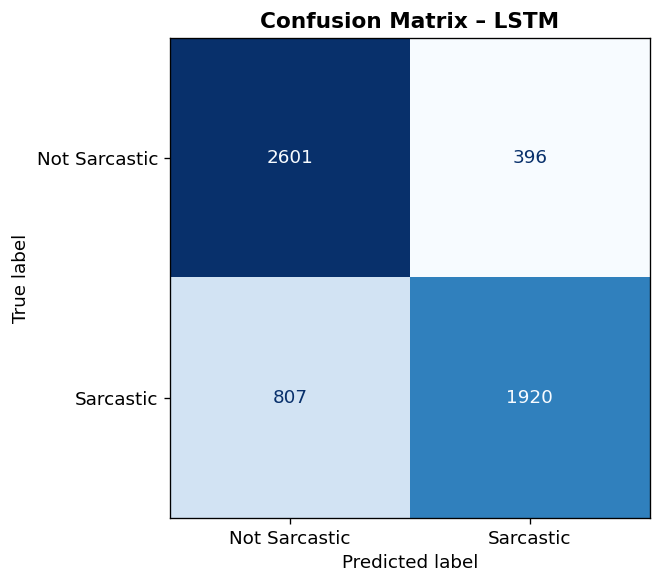

In [51]:
# Confusion Matrix – LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm,
                               display_labels=['Not Sarcastic', 'Sarcastic'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – LSTM')
plt.tight_layout()
plt.savefig('cm_lstm.png', dpi=150)
plt.show()

## Section 7: Model 3 – LSTM with Pretrained Embeddings (GloVe)

### 4.5.2 – Model 3: LSTM with Pretrained Word2Vec Embeddings

In [52]:
# Load Pretrained GloVe Embeddings via Gensim
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-twitter-50)...")
print("This may take a few minutes...")
embedding_model = api.load('glove-twitter-50')  # 50-dimensional
print("GloVe embeddings loaded!")

This may take a few minutes...
[==================================================] 100.0% 199.5/199.5MB downloaded
GloVe embeddings loaded!


In [53]:
#Build Embedding Matrix
GLOVE_DIM = 50

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f"Words found in GloVe    : {found}")
print(f"Words not found         : {not_found}")
print(f"Vocabulary coverage     : {coverage:.1f}%")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")

Words found in GloVe    : 17665
Words not found         : 2334
Vocabulary coverage     : 88.3%
Embedding matrix shape  : (20000, 50)


In [54]:
# Build LSTM + GloVe Model
def build_lstm_glove_model():
    model = models.Sequential(name='LSTM_GloVe')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # frozen pretrained embeddings
    ))
    model.add(layers.LSTM(128, return_sequences=True))
    model.add(layers.Dropout(0.3))
    model.add(layers.LSTM(64, return_sequences=False))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

lstm_glove_model = build_lstm_glove_model()
lstm_glove_model.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [55]:
#  Compile & Train LSTM + GloVe
lstm_glove_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training LSTM + GloVe...")
start = time.time()

history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True, verbose=1)],
    verbose=1
)

glove_time = time.time() - start
print(f"\nLSTM+GloVe Training time: {glove_time/60:.2f} minutes")

Training LSTM + GloVe...
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7138 - loss: 0.5552 - val_accuracy: 0.7428 - val_loss: 0.5135
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7674 - loss: 0.4844 - val_accuracy: 0.7659 - val_loss: 0.4807
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7929 - loss: 0.4446 - val_accuracy: 0.7760 - val_loss: 0.4608
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8099 - loss: 0.4156 - val_accuracy: 0.7908 - val_loss: 0.4489
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8222 - loss: 0.3908 - val_accuracy: 0.8004 - val_loss: 0.4436
Epoch 6/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8372 - loss: 0.3667 - val_accuracy: 0.8044 - val_loss: 0.4438
Epoch 7/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8469 - loss: 0.3410 - val_accuracy: 0.8061 - val_loss: 0.4547
Epoch 8/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8614 - loss

### 4.5.3 – Model 3: Training & Evaluation

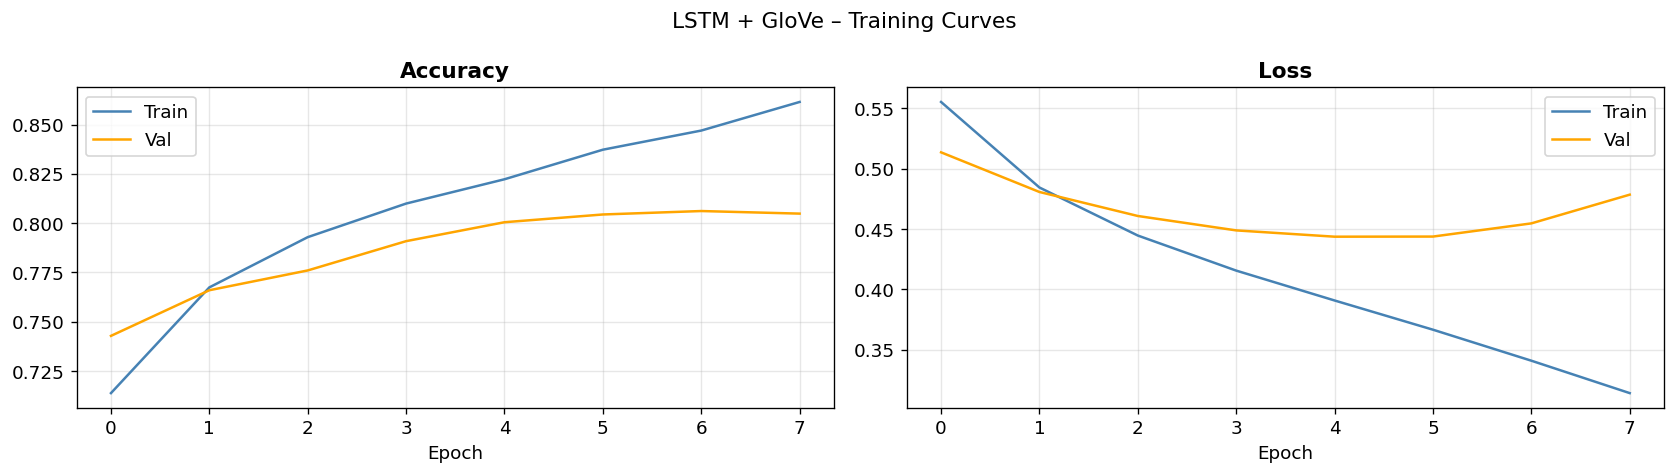

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
LSTM+GloVe – Test Accuracy: 79.05%
LSTM+GloVe – Test Loss    : 0.4697

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.76      0.88      0.81      2997
    Sarcastic       0.84      0.70      0.76      2727

     accuracy                           0.79      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.80      0.79      0.79      5724



In [56]:
# Evaluate LSTM + GloVe
plot_history(history_glove, 'LSTM + GloVe')

glove_loss, glove_acc = lstm_glove_model.evaluate(X_test_pad, y_test, verbose=0)
y_pred_glove = (lstm_glove_model.predict(X_test_pad) > 0.5).astype(int).flatten()

print(f"LSTM+GloVe – Test Accuracy: {glove_acc*100:.2f}%")
print(f"LSTM+GloVe – Test Loss    : {glove_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Not Sarcastic', 'Sarcastic']))

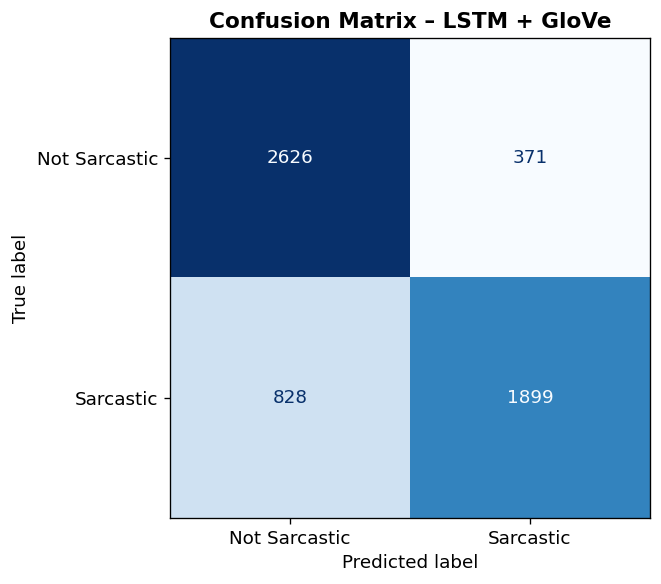

In [57]:
# Confusion Matrix – LSTM + GloVe
cm_glove = confusion_matrix(y_test, y_pred_glove)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_glove,
                               display_labels=['Not Sarcastic', 'Sarcastic'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – LSTM + GloVe')
plt.tight_layout()
plt.savefig('cm_glove.png', dpi=150)
plt.show()

Section 8: Model Comparison & Evaluation

### 4.5.3 – Compare Model 1 vs Model 2 vs Model 3

In [76]:
#  All Models Comparison Table
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4)
    }

rnn_m  = get_metrics(y_test, y_pred_rnn)
lstm_m = get_metrics(y_test, y_pred_lstm)
glv_m  = get_metrics(y_test, y_pred_glove)

results = pd.DataFrame({
    'Model':               ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Test Accuracy (%)':   [round(rnn_acc*100,2), round(lstm_acc*100,2), round(glove_acc*100,2)],
    'Test Loss':           [round(rnn_loss,4), round(lstm_loss,4), round(glove_loss,4)],
    'Precision':           [rnn_m['Precision'], lstm_m['Precision'], glv_m['Precision']],
    'Recall':              [rnn_m['Recall'], lstm_m['Recall'], glv_m['Recall']],
    'F1-Score':            [rnn_m['F1-Score'], lstm_m['F1-Score'], glv_m['F1-Score']],
    'Params':              ['~1.3M', '~2.6M', '~1.0M (frozen emb)'],
    'Training Time (min)': [round(rnn_time/60,2), round(lstm_time/60,2), round(glove_time/60,2)]
})

print("─" * 80)
print("                        MODEL COMPARISON SUMMARY")
print("─" * 80)
print(results.to_string(index=False))


────────────────────────────────────────────────────────────────────────────────
                        MODEL COMPARISON SUMMARY
────────────────────────────────────────────────────────────────────────────────
       Model  Test Accuracy (%)  Test Loss  Precision  Recall  F1-Score             Params  Training Time (min)
  Simple RNN              79.89     0.4257     0.8333  0.7224    0.7739              ~1.3M                 0.25
        LSTM              78.98     0.4363     0.8290  0.7041    0.7615              ~2.6M                 0.44
LSTM + GloVe              79.05     0.4697     0.8366  0.6964    0.7601 ~1.0M (frozen emb)                 0.44


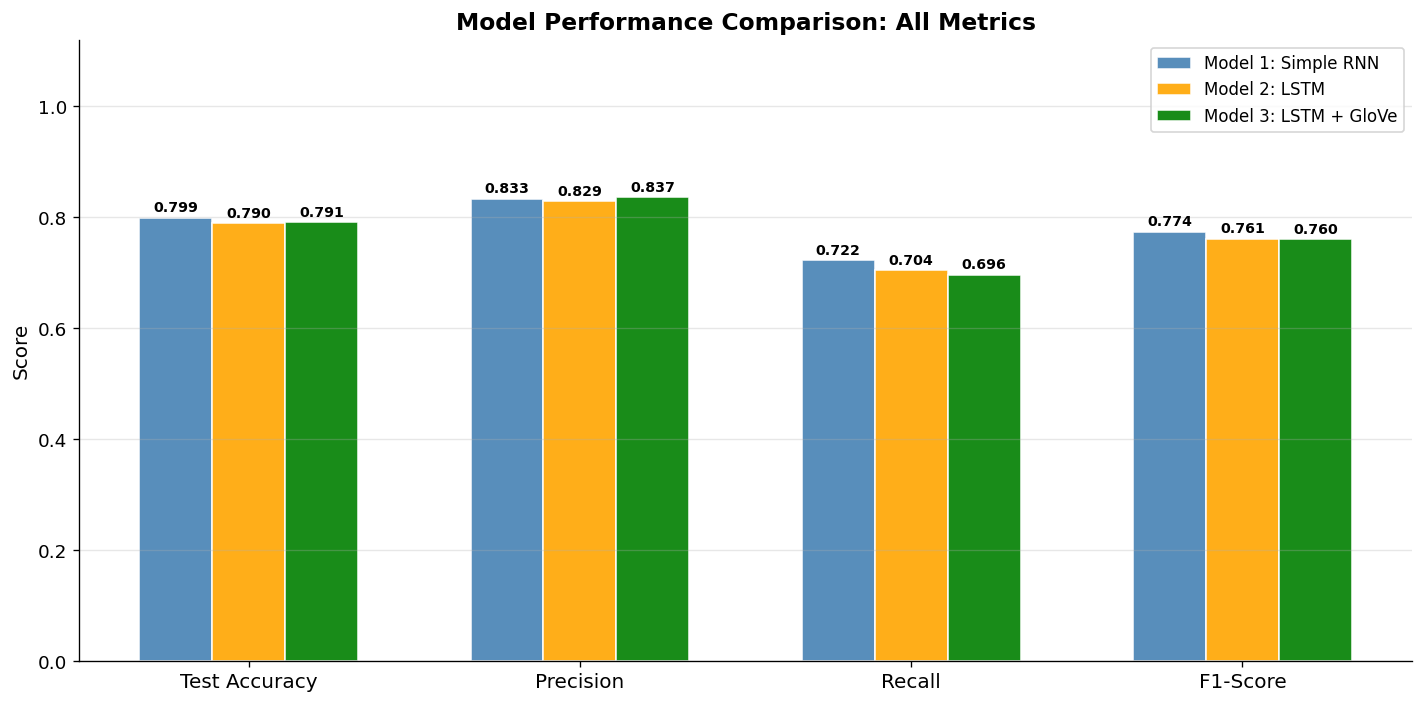

In [68]:
#  Model Performance Comparison: All Metrics
import numpy as np

model_names   = ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
metric_labels = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']

values = np.array([
    [rnn_acc,              lstm_acc,              glove_acc            ],
    [rnn_m['Precision'],   lstm_m['Precision'],   glv_m['Precision']   ],
    [rnn_m['Recall'],      lstm_m['Recall'],      glv_m['Recall']      ],
    [rnn_m['F1-Score'],    lstm_m['F1-Score'],    glv_m['F1-Score']    ],
])

x             = np.arange(len(metric_labels))
width         = 0.22
model_colors  = ['steelblue', 'orange', 'green']   # matches your other graphs

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(model_names, model_colors)):
    bars = ax.bar(x + i*width - width, values[:, i], width,
                  label=model, color=color, alpha=0.90, edgecolor='white')
    for bar, v in zip(bars, values[:, i]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('model_comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


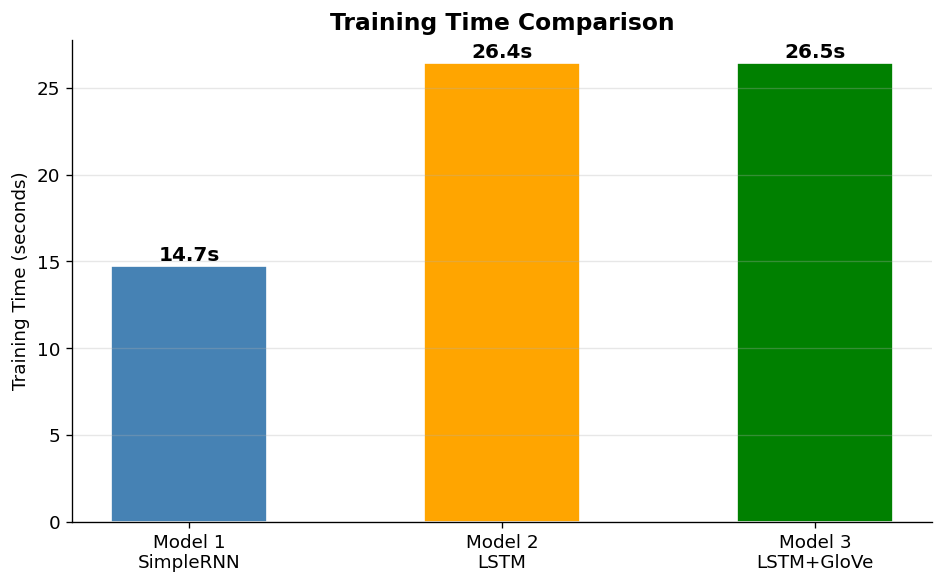

In [69]:
# Training Time Comparison
train_times_sec = [rnn_time, lstm_time, glove_time]
model_labels    = ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nLSTM+GloVe']
bar_colors      = ['steelblue', 'orange', 'green']   # matches your other graphs

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_labels, train_times_sec, color=bar_colors,
              edgecolor='white', width=0.5)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Training Time (seconds)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, t in zip(bars, train_times_sec):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{t:.1f}s', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()


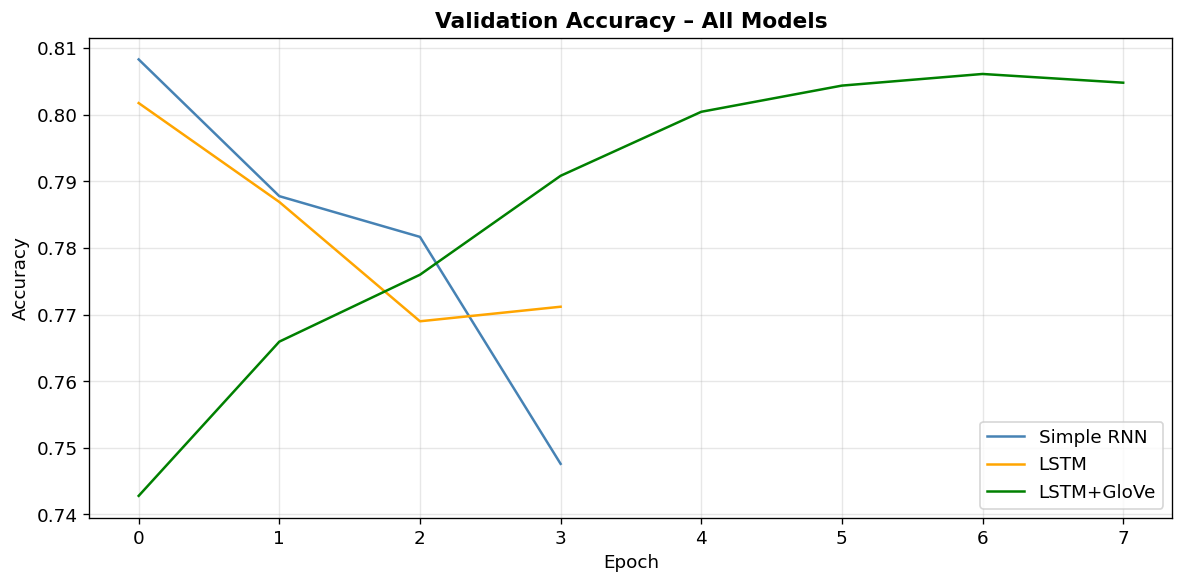

In [61]:
# All 3 Validation Accuracy Curves Together
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Simple RNN',  color='steelblue')
plt.plot(history_lstm.history['val_accuracy'],  label='LSTM',        color='orange')
plt.plot(history_glove.history['val_accuracy'], label='LSTM+GloVe',  color='green')
plt.title('Validation Accuracy – All Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_val_accuracy.png', dpi=150)
plt.show()

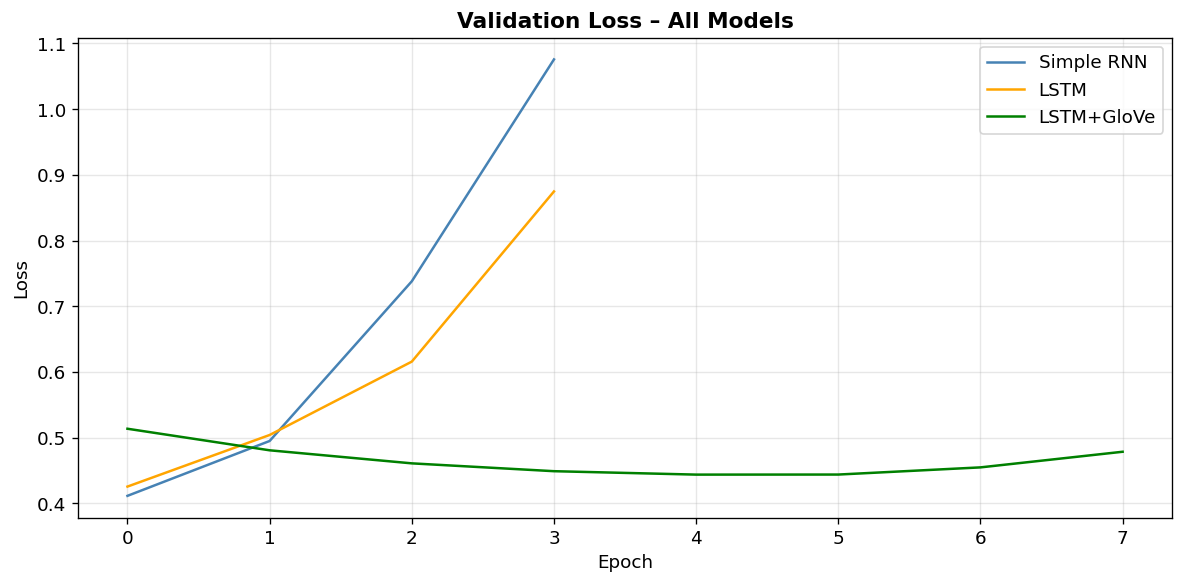

In [62]:
#  All Models – Validation Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Simple RNN',  color='steelblue')
plt.plot(history_lstm.history['val_loss'],  label='LSTM',        color='orange')
plt.plot(history_glove.history['val_loss'], label='LSTM+GloVe',  color='green')
plt.title('Validation Loss – All Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_val_loss.png', dpi=150)
plt.show()

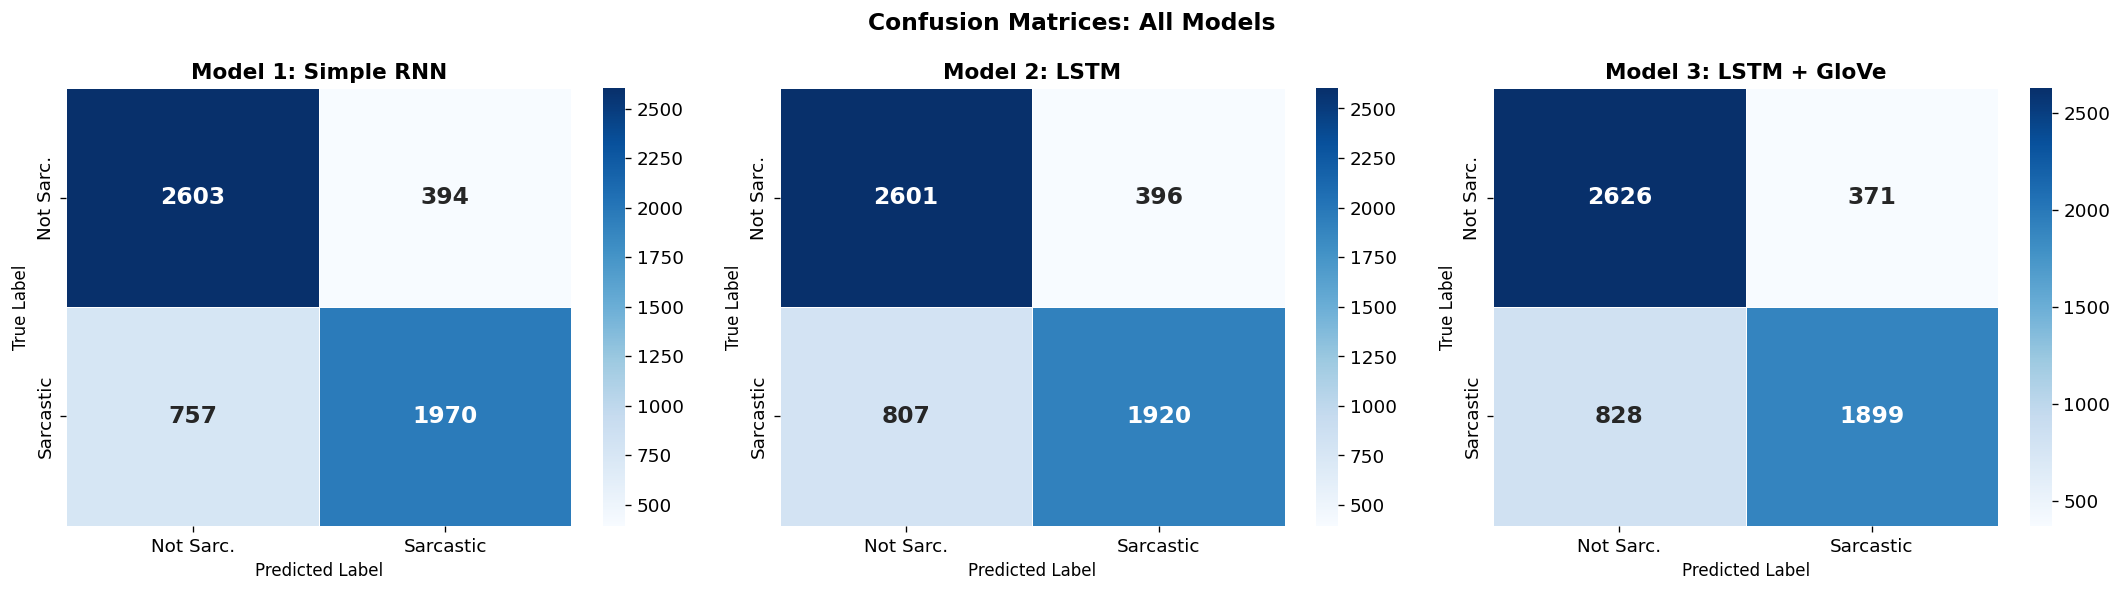

In [63]:
# Side-by-Side Confusion Matrices – All 3 Models
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: All Models', fontsize=14, fontweight='bold')

model_titles = ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
cms          = [cm_rnn, cm_lstm, cm_glove]
tick_labels  = ['Not Sarc.', 'Sarcastic']

for ax, cm, title in zip(axes, cms, model_titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax, linewidths=0.5,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()


Section 9: Error Analysis


### 4.5.4 – Analyze Misclassified Examples

In [74]:
#  Error Analysis – Misclassified Examples
# Using best model (LSTM + GloVe)
errors_idx = np.where(y_pred_glove != y_test)[0]

print(f"Total misclassified by LSTM+GloVe: {len(errors_idx)} / {len(y_test)}")
print(f"Error rate: {len(errors_idx)/len(y_test)*100:.2f}%")
print()

# Show 3 misclassified examples (as required: 2-3)
print("─" * 70)
print(" Sample Misclassified Headlines ")
print("─" * 70)
probs_glove = lstm_glove_model.predict(X_test_pad, verbose=0).flatten()
for i, idx in enumerate(errors_idx[:3]):
    prob = probs_glove[idx]
    true_label = 'Sarcastic' if y_test[idx]==1 else 'Not Sarcastic'
    pred_label = 'Sarcastic' if y_pred_glove[idx]==1 else 'Not Sarcastic'
    print(f"\nExample {i+1}:")
    print(f"  Headline   : {X_test[idx]}")
    print(f"  True Label : {true_label}")
    print(f"  Predicted  : {pred_label}  (confidence: {prob*100:.1f}%)")
    print(f"  Error Type : {'False Positive' if y_pred_glove[idx]==1 and y_test[idx]==0 else 'False Negative'}")


Total misclassified by LSTM+GloVe: 1199 / 5724
Error rate: 20.95%

──────────────────────────────────────────────────────────────────────
 Sample Misclassified Headlines 
──────────────────────────────────────────────────────────────────────

Example 1:
  Headline   : open letter editor rejecting submission victim
  True Label : Not Sarcastic
  Predicted  : Sarcastic  (confidence: 55.6%)
  Error Type : False Positive

Example 2:
  Headline   : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  True Label : Sarcastic
  Predicted  : Not Sarcastic  (confidence: 3.6%)
  Error Type : False Negative

Example 3:
  Headline   : rex tillerson call report ouster laughable
  True Label : Not Sarcastic
  Predicted  : Sarcastic  (confidence: 69.9%)
  Error Type : False Positive


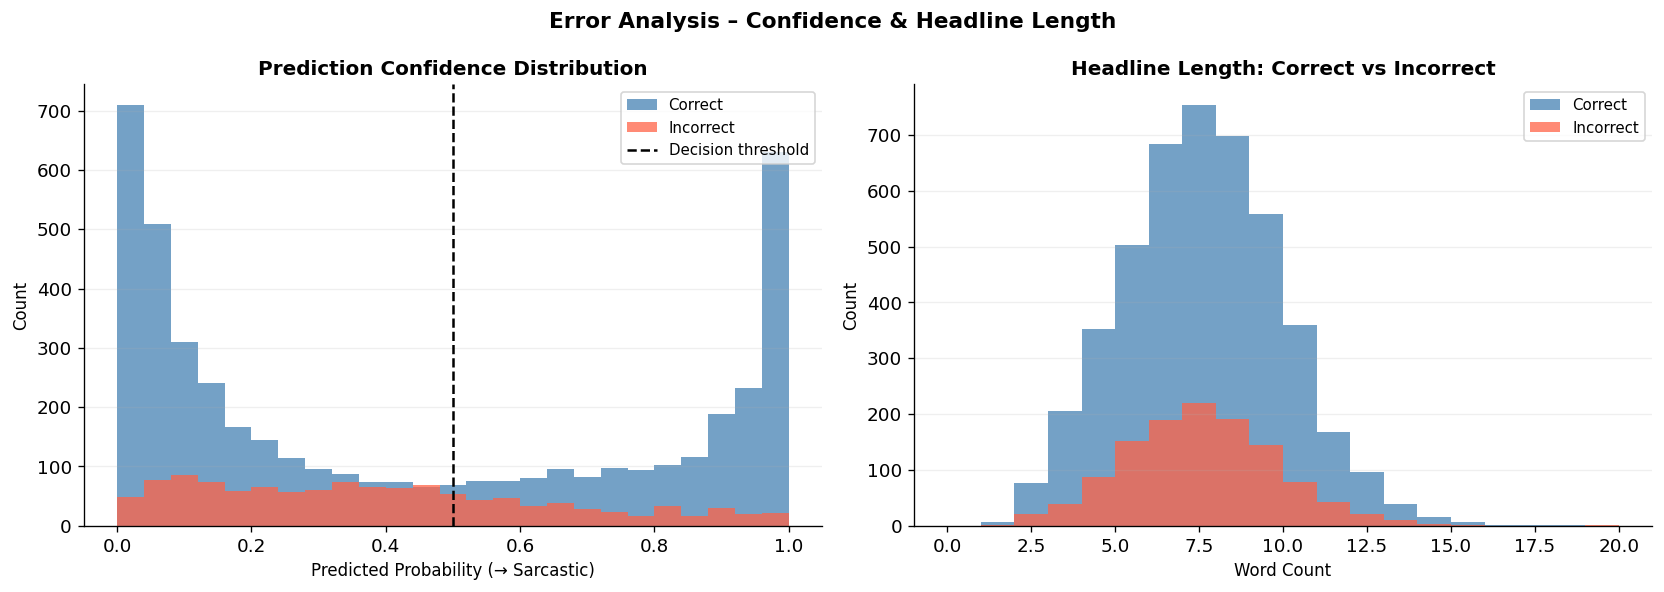


Correctly classified  : 4525 / 5724 (79.1%)
Incorrectly classified: 1199 / 5724 (20.9%)

Mean confidence on correct   predictions: 0.437
Mean confidence on incorrect predictions: 0.393


In [70]:
# Prediction Confidence Distribution & Headline Length Analysis
probs_glove    = lstm_glove_model.predict(X_test_pad, verbose=0).flatten()
correct_mask   = (y_pred_glove == y_test)
incorrect_mask = ~correct_mask

test_word_counts = np.array([len(str(h).split()) for h in X_test])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis – Confidence & Headline Length', fontsize=13, fontweight='bold')

#  Left: Prediction Confidence Distribution
ax = axes[0]
bins = np.linspace(0, 1, 26)
ax.hist(probs_glove[correct_mask],   bins=bins, alpha=0.75,
        color='steelblue', label='Correct')
ax.hist(probs_glove[incorrect_mask], bins=bins, alpha=0.75,
        color='tomato', label='Incorrect')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5,
           label='Decision threshold')
ax.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Probability (→ Sarcastic)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, axis='y')

# Right: Headline Length — Correct vs Incorrect
ax2 = axes[1]
wc_bins = np.arange(0, test_word_counts.max() + 2, 1)
ax2.hist(test_word_counts[correct_mask],   bins=wc_bins, alpha=0.75,
         color='steelblue', label='Correct')
ax2.hist(test_word_counts[incorrect_mask], bins=wc_bins, alpha=0.75,
         color='tomato', label='Incorrect')
ax2.set_title('Headline Length: Correct vs Incorrect', fontsize=12, fontweight='bold')
ax2.set_xlabel('Word Count', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('error_analysis_confidence_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrectly classified  : {correct_mask.sum()} / {len(y_test)} ({correct_mask.mean()*100:.1f}%)")
print(f"Incorrectly classified: {incorrect_mask.sum()} / {len(y_test)} ({incorrect_mask.mean()*100:.1f}%)")
print(f"\nMean confidence on correct   predictions: {probs_glove[correct_mask].mean():.3f}")
print(f"Mean confidence on incorrect predictions: {probs_glove[incorrect_mask].mean():.3f}")


In [72]:
#  Error Analysis
fp = np.sum((y_pred_glove == 1) & (y_test == 0))
fn = np.sum((y_pred_glove == 0) & (y_test == 1))

print(f"False Positives (predicted Sarcastic, actually Not): {fp}")
print(f"False Negatives (predicted Not Sarcastic, actually Is): {fn}")

print()
print("Possible reasons for errors:")
print("1. Sarcasm relies heavily on context and tone which text alone doesn't capture")
print("2. Short headlines may lack sufficient context for the model")
print("3. Subtle sarcasm without obvious markers is harder to detect")
print("4. Out-of-vocabulary words from GloVe embeddings reduce representation quality")

print()
print("Potential Improvements:")
print("1. Use larger pretrained models like BERT or RoBERTa")
print("2. Add attention mechanisms to focus on sarcastic keywords")
print("3. Use larger GloVe embeddings (100d or 200d)")
print("4. Collect more training data with diverse sarcasm styles")

False Positives (predicted Sarcastic, actually Not): 371
False Negatives (predicted Not Sarcastic, actually Is): 828

Possible reasons for errors:
1. Sarcasm relies heavily on context and tone which text alone doesn't capture
2. Short headlines may lack sufficient context for the model
3. Subtle sarcasm without obvious markers is harder to detect
4. Out-of-vocabulary words from GloVe embeddings reduce representation quality

Potential Improvements:
1. Use larger pretrained models like BERT or RoBERTa
2. Add attention mechanisms to focus on sarcastic keywords
3. Use larger GloVe embeddings (100d or 200d)
4. Collect more training data with diverse sarcasm styles


# Section 10: GUI for Real-Time Prediction

### 4.5.5 – Gradio Interface (Extra Challenge)

In [67]:
#Real-Time Sarcasm Predictor – Gradio GUI
import gradio as gr

def predict_sarcasm(headline):
    """Clean input, tokenize, pad, then predict using the best model (LSTM+GloVe)."""
    cleaned = clean_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = float(lstm_glove_model.predict(padded, verbose=0)[0][0])
    label   = " Sarcastic" if prob >= 0.5 else " Not Sarcastic"
    return f"{label}  (confidence: {prob*100:.1f}%)"

demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline here...", label="Headline"),
    outputs=gr.Textbox(label="Prediction"),
    title="Sarcasm Detector",
    description="Enter any news headline and the LSTM+GloVe model will predict whether it is sarcastic.",
    examples=[
        ["Scientists confirm that eating pizza every day is the secret to eternal happiness"],
        ["Federal Reserve raises interest rates by 25 basis points"],
        ["Local man heroically finishes entire pizza by himself while watching Netflix"],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b7b7739c6b8063b5b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Save Models

In [73]:
# Save All Models
rnn_model.save('rnn_model.h5')
lstm_model.save('lstm_model.h5')
lstm_glove_model.save('lstm_glove_model.h5')
print("All models saved!")

All models saved!
